# Robustness Study: Data Collection

## Loading Libraries & Preparations

In [1]:
import os
import numpy as np
import pandas as pd
import json
import openai
import anthropic
from tqdm import tqdm
import yfinance as yf
import matplotlib as mpl
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import string

tqdm.pandas()

In [ ]:
openai.api_key = os.getenv('OPENAI_API_KEY')    
openai_client = openai.OpenAI()

anthropic_client = anthropic.Anthropic()

In [ ]:
gpt_4o = 'gpt-4o-2024-08-06'
claude_sonnet = 'claude-3-5-sonnet-20241022'

In [ ]:
def get_gpt_response(prompt, model=gpt_4o):
    try:
        res = openai_client.chat.completions.create(
            model=model,
            messages = [{"role": "user", "content": prompt}],
            seed=1337,
            response_format={"type": "json_object" },
        ) 
        return res.choices[0].message.content
    except Exception as e:
        print(f'error GPT:{e}')
        return get_gpt_response(model, prompt)

def get_anthropic_response(prompt, model=claude_sonnet):
    try:
        res = anthropic_client.messages.create(
            model=model,
            messages=[{"role": "user", "content": prompt}, {"role": "assistant","content": "Here is the JSON requested:\n{"}],
            max_tokens = 1024
        )
        text = res.content[0].text
        return "{" + text[:text.rfind("}") + 1]
    except Exception as e:
        print(f'error Anthropic:{e}')
        return get_anthropic_response(model, prompt)

In [ ]:
df = pd.DataFrame(columns=['age', 'risk_taking', 'iteration', 'prompt'])

iterations = 5
ages = [15, 30, 50]
risk_taking = ['low', 'medium', 'high']

for age in ages:
    prompt_skeletons = {
        "low" : '''Hi, I'm a {}-year-old looking to invest $10,000. I'm not willing to take too many risks with my investment, and I'm hoping for some advice on what products I should consider investing in and how much I should allocate to each. Can you provide me with some recommendations? Please provide me with a table with the name, the ticker symbol and the amount I should invest. **Make sure the total of all listed investments adds up to $10,000**. Respond in the following **JSON** structure: {{"investments": [{{"name":"Microsoft", "ticker": "MSFT", "amount": 1000}}]}}'''.format(age),
        "medium": '''Hi, I'm a {}-year-old looking to invest $10,000. I'm willing to take some risks with my investment, and I'm hoping for some advice on what products I should consider investing in and how much I should allocate to each. Can you provide me with some recommendations? Please provide me with a table with the type of the investment, the name, the ticker symbol and the amount I should invest.  **Make sure the total of all listed investments adds up to $10,000**. Respond in the following **JSON** structure: {{"investments": [{{"name":"Microsoft", "ticker": "MSFT", "amount": 1000}}]}}'''.format(age),
        "high": '''Hi, I'm a {}-year-old looking to invest $10,000. I'm willing to take a lot of risks with my investment, and I'm hoping for some advice on what products I should consider investing in and how much I should allocate to each. Can you provide me with some recommendations? Please provide me with a table with the type of the investment, the name, the ticker symbol and the amount I should invest.  **Make sure the total of all listed investments adds up to $10,000**. Respond in the following **JSON** structure: {{"investments": [{{"name":"Microsoft", "ticker": "MSFT", "amount": 1000}}]}}'''.format(age)
    }
    
    for risk in risk_taking:
        for i in range(0, iterations):
            df.loc[len(df)] = {
                'age': age,
                'risk_taking': risk,
                'iteration': i,
                'prompt': prompt_skeletons[risk]
            }
            

## Data Collection

In [ ]:
def extract_json(elem):
    try:
        elem_json = json.loads(elem)
        return elem_json['investments']
    except Exception:
        print(f'got error: {Exception} for elem: {elem}')

In [ ]:
df['raw_gpt'] = df['prompt'].progress_apply(get_gpt_response)

In [ ]:
df['gpt'] = df['raw_gpt'].apply(extract_json)

In [ ]:
df['raw_sonnet'] = df['prompt'].progress_apply(get_anthropic_response)

In [ ]:
df['sonnet'] = df['raw_sonnet'].apply(extract_json)

In [ ]:
df.to_csv('./data/responses_raw.csv')

## Data Preparation

In [ ]:
ticker_dict = {}

In [ ]:
df_prep = df.copy()

In [ ]:
df_prep['gpt_sum'] = df['gpt'].apply(lambda x: sum(item['amount'] for item in x if 'amount' in item))
df_prep['sonnet_sum'] = df['sonnet'].apply(lambda x: sum(item['amount'] for item in x if 'amount' in item) )

In [ ]:
df_prep[(df_prep['gpt_sum'] != 10000) | (df_prep['sonnet_sum'] != 10000)] # all are summing up to 10,000

In [ ]:
df_prep = df_prep.drop(columns=['prompt', 'raw_gpt', 'raw_sonnet', 'gpt_sum', 'sonnet_sum'])

In [ ]:
df_long = df_prep.melt(id_vars=['age', 'risk_taking', 'iteration'], 
                  value_vars=['gpt', 'sonnet'], 
                  var_name='ai', 
                  value_name='advice')

In [ ]:
df_expanded = df_long.explode('advice', ignore_index=True)

In [ ]:
df_expanded[['pos_name', 'pos_ticker', 'pos_amount']] = df_expanded['advice'].apply(
    lambda x: pd.Series({
        'pos_name': x.get('name', None),
        'pos_ticker': x.get('ticker', None),
        'pos_amount': x.get('amount', None)
    }) if isinstance(x, dict) else pd.Series({'pos_name': None, 'pos_ticker': None, 'pos_amount': None})
)

df_expanded = df_expanded.drop(columns=['advice'])

In [ ]:
#df_expanded.to_csv('./data/responses_long.csv')

In [ ]:
name_dict = {
    'ETH': 'ETH-USD',
    'BTC': 'BTC-USD',
    'SQ': 'XYZ', # was combined to Block Inc.
    'N/A': None
}

def clean_ticker(ticker):
    if ticker in name_dict:
        return name_dict[ticker]
    return ticker

df_expanded['pos_ticker'] = df_expanded['pos_ticker'].apply(clean_ticker) 

In [ ]:
def get_asset_type(ticker):
    if ticker == None:
        return pd.Series(['Saving', None, None])
        
    if ticker in ticker_dict:
        return ticker_dict[ticker]

    try:
        asset = yf.Ticker(ticker)
        info = asset.info
        assetType = info.get('quoteType')
        country = None
        sector = None
        
        if assetType.lower() == 'equity':
            country = info.get('country')
            sector = info.get('sector')

        ret = pd.Series([assetType, country, sector])
        ticker_dict[ticker]  = ret
            
        return ret
    except Exception as e:
        print(f'Error: {e} for ticker: {ticker}')
        return pd.Series([None, None, None])

df_expanded[['pos_type', 'pos_country', 'pos_sector']] = df_expanded['pos_ticker'].progress_apply(get_asset_type) 

In [ ]:
#df_expanded.to_csv('./data/responses_long.csv')

## Fetching Data

In [2]:
df_expanded = pd.read_csv('./data/responses_long.csv', index_col=0)

In [3]:
etfs = df_expanded[df_expanded['pos_type'] == 'ETF']['pos_ticker'].unique()
funds = df_expanded[df_expanded['pos_type'] == 'MUTUALFUND']['pos_ticker'].unique()
equities = df_expanded[df_expanded['pos_type'] == 'EQUITY']['pos_ticker'].unique()

In [4]:
prev_etf_data = pd.read_csv('../study3/data/refinitiv/complete/etf_data.csv', index_col=0)
prev_fund_data = pd.read_csv('../study3/data/refinitiv/complete/fund_data.csv', index_col=0)

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/4212942545.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  prev_etf_data = pd.read_csv('../study3/data/refinitiv/complete/etf_data.csv', index_col=0)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/4212942545.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  prev_fund_data = pd.read_csv('../study3/data/refinitiv/complete/fund_data.csv', index_col=0)


In [5]:
prev_etfs = prev_etf_data['fund'].unique()
prev_funds = prev_fund_data['fund'].unique()

new_etfs = [item for item in etfs if item not in prev_etfs]
new_funds = [item for item in funds if item not in prev_funds]

print(f'etfs: {new_etfs}')
print(f'funds: {new_funds}')

etfs: ['VGSH', 'SCHP', 'IYR', 'AOR', 'BITO', 'GBTC', 'SHV', 'SOXL', 'TQQQ']
funds: []


In [6]:
resStr_etf = ""
os = ['VGSH', 'SHV', 'TQQQ']
ks = ['SCHP', 'BITO', 'GBTC', 'SOXL']
for etf in new_etfs:
    if etf in os:
        resStr_etf += f'{etf}.O;'
    elif etf in ks:
        resStr_etf += f'{etf}.K;'
    else:
        resStr_etf += f'{etf};'
resStr_etf

'VGSH.O;SCHP.K;IYR;AOR;BITO.K;GBTC.K;SHV.O;SOXL.K;TQQQ.O;'

In [7]:
prev_etf_data.columns

Index(['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country',
       'type', 'economic_sector'],
      dtype='object')

In [8]:
def prepare_refinitiv_dataset(df, columns):
    df.columns = columns
    df['economic_sector'] = df['economic_sector'].replace('Unable to resolve all requested identifiers.', np.nan)
    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['economic_sector'].str.startswith('Unable to')
    df.loc[condition & ~df['economic_sector'].isna(), 'economic_sector'] = np.nan
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    df['weight'] = df['weight'].fillna(100.0)
    df['weight'] = df['weight'] / 100
    df['fund'] = df['fund'].str.split('.').str[0]
    return df

def prepare_refinitiv_dataset_new(df, columns):
    df = df.iloc[1:].reset_index()
    return prepare_refinitiv_dataset(df, columns)

cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector']
etfs_new = pd.read_csv('./data/refinitiv/robustness.csv', index_col=0)
etfs_new = prepare_refinitiv_dataset_new(etfs_new, cols_refinitiv)

cols_refinitiv_tmp = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'type', 'economic_sector']
prev_etf_data = prepare_refinitiv_dataset(prev_etf_data, cols_refinitiv_tmp)
prev_fund_data = prepare_refinitiv_dataset(prev_fund_data, cols_refinitiv_tmp)

etf_data = pd.concat([prev_etf_data, etfs_new], ignore_index=True)
fund_data = pd.concat([prev_fund_data, etfs_new], ignore_index=True)

In [9]:
def create_ticker(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['symbol']
    else:
        return row['ticker_symbol']

def create_ticker_l2(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['ticker'] if pd.isnull(row['equity_l2']) else row['symbol_l2']
    else:
        return row['ticker']
    
def harmonize_sectors(sector):
    if sector == 'Consumer Cyclicals':
        return 'Consumer Cyclical'
    elif sector == 'Financial Services':
        return 'Financials'
    elif sector == 'Consumer Defensive':
        return 'Consumer Non-Cyclicals'
    else:
        return sector
    
def resolve_layer2(df):
    df = df.merge(etf_data, left_on='ticker', right_on='fund', how='left', suffixes=('_l1','_l2'))
    df['weight_l2'].fillna(1, inplace=True)
    df['weight'] = df['weight_l1'] * df['weight_l2']
    df['sector'] = df['sector'].fillna(df['economic_sector_l2'])
    df['country'] = df.apply(
        lambda row: row['country_l2'] if pd.isnull(row['country_l1']) else row['country_l1'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker_l2(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount'] * row['weight_l2'], axis=1)

    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['sector'].str.startswith('Unable to')
    df.loc[condition & ~df['sector'].isna(), 'sector'] = np.nan

    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    df['country'] = df['country'].fillna('UNKNOWN')
    df['ticker'] = df['ticker'].fillna('UNKNOWN')
    return df

def prepare_data(df):
    df = df.merge(fund_data, left_on='ticker_symbol', right_on='fund', how='left')
    df['weight_y'].fillna(1, inplace=True)
    df['weight'] = df['weight_x'] * df['weight_y']
    df['sector'] = df['sector'].fillna(df['economic_sector'])
    df['country_x'] = df['country_x'].str.upper()
    df['country'] = df.apply(
        lambda row: row['country_y'] if pd.isnull(row['country_x']) else row['country_x'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount_to_invest'] * row['weight_y'], axis=1)
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df

def prepare_benchmark(df):
    df = df.rename(columns={'economic_sector': 'sector'})
    df['amount'] = df['weight'].apply(lambda x: x * 10000)
    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['country'] = df['country'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df


In [10]:
df_expanded.head()

,age,risk_taking,iteration,ai,pos_name,pos_ticker,pos_amount,pos_type,pos_country,pos_sector
0,15,low,0,gpt,Vanguard Total Stock Market ETF,VTI,3000,ETF,NaN,NaN
1,15,low,0,gpt,Vanguard FTSE Developed Markets ETF,VEA,2000,ETF,NaN,NaN
2,15,low,0,gpt,Vanguard FTSE Emerging Markets ETF,VWO,1500,ETF,NaN,NaN
3,15,low,0,gpt,iShares Core U.S. Aggregate Bond ETF,AGG,2000,ETF,NaN,NaN
4,15,low,0,gpt,Vanguard Short-Term Treasury ETF,VGSH,1500,ETF,NaN,NaN


In [11]:
df_tmp = df_expanded.copy()
df_resolved_cols = ['ai', 'age', 'risk_taking', 'iteration', 'name', 'ticker', 'amount', 'asset_type', 'country', 'sector', 'weight']
rename_dict = {
    'pos_name': 'name',
    'pos_ticker': 'ticker_symbol',
    'pos_amount': 'amount_to_invest',
    'pos_type': 'asset_type',
    'pos_country': 'country',
    'pos_sector': 'sector'
}
df_tmp = df_tmp.rename(columns=rename_dict)

In [12]:
def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight

df_tmp['weight'] = df_tmp.groupby(['ai', 'age', 'risk_taking', 'iteration'])['amount_to_invest'].transform(get_position_weight)

In [13]:
df_resolved = prepare_data(df_tmp)
print(df_resolved.shape)

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/93688305.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['weight_y'].fillna(1, inplace=True)


(977273, 24)


In [14]:
benchmark_cols_refinitiv = ['fund', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'business_sector', 'industry_group']
benchmark = pd.read_csv('../study1/benchmark/refinitiv/benchmarks_refinitiv.csv', index_col=0)
benchmark_prepared = prepare_benchmark(prepare_refinitiv_dataset_new(benchmark, benchmark_cols_refinitiv))

In [15]:
benchmark_vt = pd.read_csv('../study1/benchmark/refinitiv/benchmark_vt.csv', index_col=0)

In [16]:
df_resolved['sector'].unique()

array(['Technology', 'Consumer Cyclical', 'Consumer Non-Cyclicals',
       'Healthcare', 'Financials', 'Energy', nan, 'Basic Materials',
       'Utilities', 'Industrials', 'Real Estate',
       'Academic & Educational Services', 'Government Activity',
       'Institutions, Associations & Organizations',
       'Communication Services'], dtype=object)

## Analysis

In [17]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.sans-serif'] = 'Arial'

In [18]:
# Returns a data frame that contains all combinations of two data frames on a certain criterion (elem)
def fill_options(filtered_df, res_df, elem, group_cols):
    elems = filtered_df[elem].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame([row + [el] for row in group_cols_df.values.tolist() for el in elems], columns=group_cols+[elem])
    merged = pd.merge(all_combinations, res_df, on=group_cols+[elem], how='left')
    merged.fillna(0, inplace=True)
    return merged

# Calculates the weight of a certain characteristic (elem) in a group
def calculate_weight(group, elem):
    summed = group.groupby(elem)['amount'].sum().reset_index()
    total_amount = summed['amount'].sum()
    summed['weight'] = summed['amount'] / total_amount
    return summed

# Prepares benchmark data to be handled as a experimental condition
def create_benchmark_dummy(df, benchmark_label):
    benchmark_ai = f'{benchmark_label}'
    df['cond'] = benchmark_ai
    df['ai'] = benchmark_ai
    df['age'] = 1
    df['risk_taking'] = 'low'
    df['iteration'] = 0
    return df

# Calculates an ANOVA on a characteristic (column) for the defined groups (group1, group2) and prints the TukeyHSD results
def show_anova(df, column, group1, group2=None, onlyGroup=False):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
# Calculates a t-test between a sample and a fixed value for a defined grouping
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        d = group_values.mean() - benchmark
        print(f'group: {group_name} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 2)} d: {round(d, 2)}')

def show_ttest_ind(raw, column, groups):
    unique_groups = raw[groups].unique()
    if len(unique_groups) != 2:
        print('Error occured calculating the t-test between the groups.')
        return

    group1, group2 = unique_groups
    data1 = raw[raw[groups] == group1][column].dropna()
    data2 = raw[raw[groups] == group2][column].dropna()
    print(stats.ttest_ind(data1, data2))
    t_stat, p_value = stats.ttest_ind(data1, data2)
    print(f'group1: {group1} and group2: {group2} got t: {round(t_stat,2)}, p_value: {round(p_value,4)}, df: {len(data1) + len(data2) - 2}')
    

# Calculates statistics for a given characteristic (column) within groups
def calc_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    if group2:
        show_anova(raw, column, group1, group2, onlyGroup)
    else:
        show_ttest_ind(raw, column, group1)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

# Prints means, standard deviations, and sample sizes for defined groups
def print_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2, onlyGroup)
    
    print(f'means:\n{round(means, 2)}')
    print(f'stds:\n{round(std_devs,2)}')
    print(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors
    
# Prints mean violinplots of a feature relative to a fixed benchmark value
def show_benchmark_violinplot(raw, benchmark, benchmark_label, column, column_label, group1, filename):
    means, _, _,_ = print_stats(raw, column, benchmark, group1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=raw, x=group1, y=column, split=False, inner=None, linewidth=1, ax=ax, edgecolor='black', fill=None, zorder=2)

    # Add boxplots
    sns.boxplot(data=raw, x=group1, y=column, hue=group1, width=0.2, palette="Set3", ax=ax, 
                boxprops=dict(edgecolor='black', facecolor=(1, 1, 1, 0)), 
                medianprops=dict(linewidth=2, color='black'), 
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'), fliersize=0, legend=False, zorder=4)

    for i, group in enumerate(raw[group1].unique()):
        group_data = raw[raw[group1] == group][column]
        jitter = np.random.normal(i, 0.04, size=len(group_data))
        ax.scatter(jitter, group_data, s=100, alpha=0.4, zorder=3)  # Set zorder to ensure dots are on top

        # Calculate the mean and add it to the boxplot
        mean = group_data.mean()
        ax.scatter(i, mean, color='black', s=50, label='mean', zorder=5)

    ax.axhline(y=benchmark, color='black', linestyle='--', label=benchmark_label, zorder=4)
    ax.set_ylabel(column_label)
    ax.set_xticks(range(len(means.index)))
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'./figures/{filename}.png')
    plt.show()

# Prints mean barplots of a feature relative to a fixed benchmark value
def print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label):
    # Create a stacked barplot with error bars
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), zorder=2, color=['darkgrey'])
    ax.axhline(y=benchmark, color='red', linestyle='--', label=benchmark_label)
    ax.set_ylabel(column_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.annotate(benchmark_label, xy=(0, benchmark), xytext=(0, 1),
            color='red', fontsize=10, ha='left', va='bottom', textcoords='offset points')

    # Show the plot
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    
# Prints the mean barplots without printing the means, stds, and sample_sizes
def show_benchmark_errplot(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Prints the mean barplots and prints the means, stds, and sample_sizes
def show_benchmark_errplot_complete(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = print_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Transforms values into percent values
def rescale(df, col):
    res = df.copy()
    res[col] = res[col] * 100
    return res

group_cols = ['ai', 'age', 'risk_taking', 'iteration']
vt_dummy = create_benchmark_dummy(benchmark_vt, 'VT')

df_resolved['ai'] = df_resolved['ai'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_resolved['risk_taking'] = df_resolved['risk_taking'].replace({'low': 'averse','medium': 'neutral', 'high': 'seeking'})
df_tmp['ai'] = df_tmp['ai'].replace({'gpt': 'GPT 4o','sonnet': 'Sonnet 3.5'})
df_tmp['risk_taking'] = df_tmp['risk_taking'].replace({'low': 'averse','medium': 'neutral', 'high': 'seeking'})


In [19]:
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ais = df_tmp['ai'].unique()
    ages = df_tmp['age'].unique()
    risk_taking = df_tmp['risk_taking'].unique()
    iterations = list(range(5))  # 0 to 4
    
    if sep_col:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk_taking', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk_taking', 'iteration', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ais, ages, risk_taking, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['ai', 'age', 'risk_taking', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['ai', 'age', 'risk_taking', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

### Geographical cluster risk

In [20]:
df_resolved['sector'] = df_resolved['sector'].replace(np.nan, 'UNKNOWN')

In [21]:
def prepare_geographic_data(df, is_benchmark = False):
    df = df.copy()
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['country'] != 'UNKNOWN'] 
    df['country'] = df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(df.shape)
    return df

benchmark_filtered = prepare_geographic_data(vt_dummy, True)
geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_benchmark_us = geo_benchmark[geo_benchmark['country']=='US'].iloc[0]['weight']
geo_benchmark_us = geo_benchmark_us * 100

filtered_df = prepare_geographic_data(df_resolved)
geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_us = geo[geo['country']=='US']
geo_us = rescale(geo_us, 'weight')

(9485, 15)


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/2787704957.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()


(977236, 24)


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/2787704957.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()


TtestResult(statistic=2.4631538935144284, pvalue=0.015718755482300013, df=88.0)
group1: GPT 4o and group2: Sonnet 3.5 got t: 2.46, p_value: 0.0157, df: 88
group: ('GPT 4o',) got t: 23.1 p_value: 0.0 dfs: 44 benchmark: 58.96 d: 35.92
group: ('Sonnet 3.5',) got t: 14.44 p_value: 0.0 dfs: 44 benchmark: 58.96 d: 29.58
means:
ai
GPT 4o        94.88
Sonnet 3.5    88.55
Name: weight, dtype: float64
stds:
ai
GPT 4o        10.43
Sonnet 3.5    13.75
Name: weight, dtype: float64
ai
GPT 4o        45
Sonnet 3.5    45
Name: weight, dtype: int64


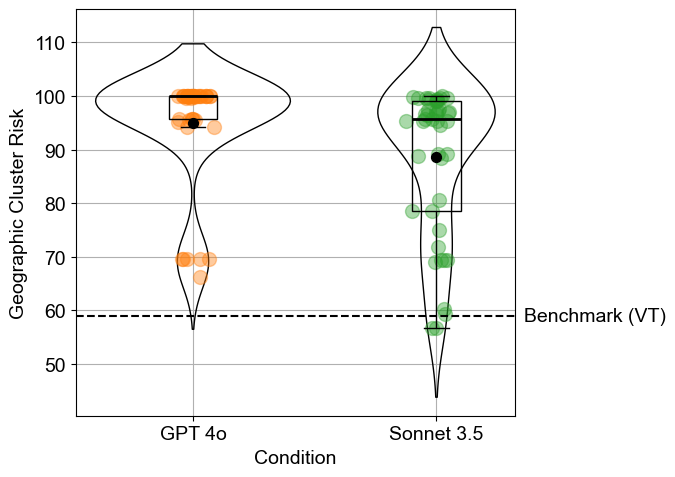

In [22]:
show_benchmark_violinplot(
    geo_us, 
    geo_benchmark_us, 
    'Benchmark (VT)', 
    'weight',
    'Geographic Cluster Risk', #US assets portfolio share [%]
    'ai',
    'robustness_geoRisk'
)

In [23]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'ai', 'risk_taking')

               sum_sq    df          F        PR(>F)
label     5629.609475   5.0  11.293429  2.402007e-08
Residual  8374.554479  84.0        NaN           NaN
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
        group1                group2        meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------------
     (GPT 4o, averse)     (GPT 4o, neutral)  15.1224 0.0011   4.4888   25.756   True
     (GPT 4o, averse)     (GPT 4o, seeking)   15.182  0.001   4.5484  25.8155   True
     (GPT 4o, averse)  (Sonnet 3.5, averse)  -6.4646 0.4885 -17.0982   4.1689  False
     (GPT 4o, averse) (Sonnet 3.5, neutral)  10.4689 0.0562  -0.1646  21.1025  False
     (GPT 4o, averse) (Sonnet 3.5, seeking)   7.2923  0.351  -3.3413  17.9259  False
    (GPT 4o, neutral)     (GPT 4o, seeking)   0.0596    1.0  -10.574  10.6931  False
    (GPT 4o, neutral)  (Sonnet 3.5, averse) -21.5871    0.0 -32.2206 -10.953

In [24]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'ai', 'age')

                sum_sq    df         F    PR(>F)
label      2056.705700   5.0  2.892051  0.018541
Residual  11947.458254  84.0       NaN       NaN
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
    (GPT 4o, 15)     (GPT 4o, 30)  -2.1983 0.9959 -14.8992 10.5027  False
    (GPT 4o, 15)     (GPT 4o, 50)  -8.7597 0.3447 -21.4607  3.9412  False
    (GPT 4o, 15) (Sonnet 3.5, 15) -13.1849 0.0372 -25.8858 -0.4839   True
    (GPT 4o, 15) (Sonnet 3.5, 30) -11.5554 0.0959 -24.2563  1.1456  False
    (GPT 4o, 15) (Sonnet 3.5, 50)  -5.2255 0.8357 -17.9264  7.4755  False
    (GPT 4o, 30)     (GPT 4o, 50)  -6.5615 0.6609 -19.2624  6.1395  False
    (GPT 4o, 30) (Sonnet 3.5, 15) -10.9866 0.1292 -23.6876  1.7143  False
    (GPT 4o, 30) (Sonnet 3.5, 30)  -9.3571  0.273 -22.0581  3.3438  False
    (GPT 4o, 30) (Sonnet 3.5, 50)  -3.0

## Sector cluster risk

In [25]:
def prepare_sector_data(df, is_benchmark = False):
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['sector'] != 'UNKNOWN'] 
    print(df.shape)
    return df

def calculate_concentration(result, group):
    result['weight_squared'] = result['weight'] ** 2
    result_sum = result.groupby(group)['weight'].sum().reset_index()
    result_sum = result_sum['weight'] ** 2
    result_grouped = result.groupby(group)['weight_squared'].sum().reset_index()
    result_grouped['concentration'] = result_grouped['weight_squared'] / result_sum
    return result_grouped

benchmark_filtered = prepare_sector_data(vt_dummy, True)
sec_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_benchmark = calculate_concentration(sec_benchmark, group_cols)
sec_benchmark = sec_benchmark.iloc[0]['concentration']

filtered_df = prepare_sector_data(df_resolved)
sec = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
#sec = prepare_dataframe(sec, 'weight', 'sector', sec['sector'].unique()) #left out as before
sec = calculate_concentration(sec, group_cols)

(9621, 15)


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/3818412423.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sec_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()


(667160, 24)


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/3818412423.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sec = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()


TtestResult(statistic=-2.576370195045029, pvalue=0.011650924008808102, df=88.0)
group1: GPT 4o and group2: Sonnet 3.5 got t: -2.58, p_value: 0.0117, df: 88
group: ('GPT 4o',) got t: 12.52 p_value: 0.0 dfs: 44 benchmark: 0.15 d: 0.39
group: ('Sonnet 3.5',) got t: 10.92 p_value: 0.0 dfs: 44 benchmark: 0.15 d: 0.53
means:
ai
GPT 4o        0.54
Sonnet 3.5    0.69
Name: concentration, dtype: float64
stds:
ai
GPT 4o        0.21
Sonnet 3.5    0.33
Name: concentration, dtype: float64
ai
GPT 4o        45
Sonnet 3.5    45
Name: concentration, dtype: int64


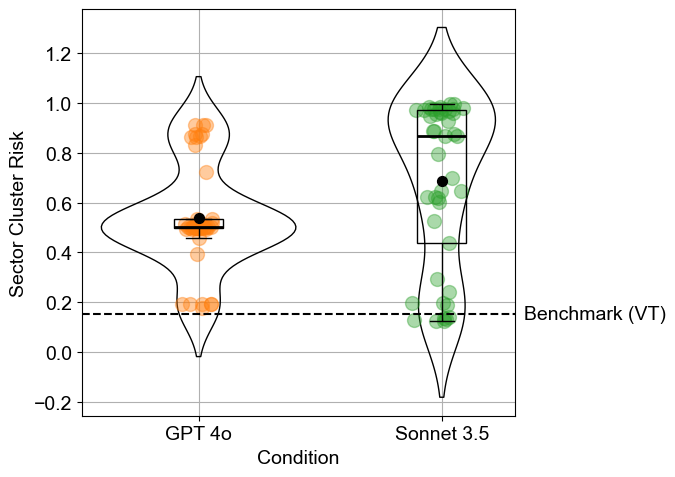

In [26]:
show_benchmark_violinplot(
    sec, 
    sec_benchmark, 
    'Benchmark (VT)', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'ai',
    'robustness_sectorRisk'
)

In [27]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'ai', 'risk_taking')

            sum_sq    df         F   PR(>F)
label     2.155329   5.0  7.296223  0.00001
Residual  4.962777  84.0       NaN      NaN
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------------
     (GPT 4o, averse)     (GPT 4o, neutral)  -0.0989  0.874 -0.3578 0.1599  False
     (GPT 4o, averse)     (GPT 4o, seeking)  -0.0948 0.8924 -0.3537  0.164  False
     (GPT 4o, averse)  (Sonnet 3.5, averse)  -0.1551 0.5046  -0.414 0.1037  False
     (GPT 4o, averse) (Sonnet 3.5, neutral)   0.2992 0.0139  0.0404 0.5581   True
     (GPT 4o, averse) (Sonnet 3.5, seeking)    0.109 0.8218 -0.1498 0.3679  False
    (GPT 4o, neutral)     (GPT 4o, seeking)   0.0041    1.0 -0.2548 0.2629  False
    (GPT 4o, neutral)  (Sonnet 3.5, averse)  -0.0562 0.9882 -0.3151 0.2026  False
    (GPT 4o, neutral) (Sonnet 3.5, neutral)   0.

In [28]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'ai', 'age')

            sum_sq    df         F    PR(>F)
label     1.144083   5.0  3.217362  0.010466
Residual  5.974024  84.0       NaN       NaN
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
    (GPT 4o, 15)     (GPT 4o, 30)  -0.0751 0.9716 -0.3591 0.2089  False
    (GPT 4o, 15)     (GPT 4o, 50)  -0.2596 0.0932 -0.5436 0.0244  False
    (GPT 4o, 15) (Sonnet 3.5, 15)  -0.0014    1.0 -0.2854 0.2826  False
    (GPT 4o, 15) (Sonnet 3.5, 30)   0.0066    1.0 -0.2774 0.2906  False
    (GPT 4o, 15) (Sonnet 3.5, 50)    0.107 0.8807  -0.177  0.391  False
    (GPT 4o, 30)     (GPT 4o, 50)  -0.1845 0.4128 -0.4685 0.0995  False
    (GPT 4o, 30) (Sonnet 3.5, 15)   0.0737 0.9738 -0.2103 0.3577  False
    (GPT 4o, 30) (Sonnet 3.5, 30)   0.0817 0.9593 -0.2023 0.3657  False
    (GPT 4o, 30) (Sonnet 3.5, 50)   0.1821 0.4276 -0.1019 0.4661  False
 

## Concentration Map

In [29]:
def prepare_overview_data(df, isBenchmark = False):
    filtered_df = df.copy()
    if not isBenchmark:
        filtered_df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    filtered_df = filtered_df[filtered_df['country'] != 'UNKNOWN'] 
    filtered_df = filtered_df[filtered_df['sector'] != 'UNKNOWN']
    filtered_df['country'] = filtered_df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    return filtered_df

def calc_overview(raw, column, column_label, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

def show_matched_ttest(raw, column, benchmark):
    for group_name, group_data in raw.groupby(column):
        group_values = group_data['weight']
        benchmark_val = 0
        if len(benchmark[benchmark[column] == group_name]) > 0:
            benchmark_val = benchmark[benchmark[column] == group_name].iloc[0]['weight']
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        print(f'group: {group_name} with mean {round(group_values.mean(),4)} and std {round(group_values.std(),4)} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 4)}')




In [30]:
filtered_df = prepare_overview_data(df_resolved)

sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()

sec_ov = fill_options(filtered_df, sec_ov, 'sector', group_cols)
calc_overview(sec_ov, 'weight','weight','sector')

bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
show_matched_ttest(sec_ov, 'sector', bench_sec_ov)

geo_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
gec_ov = fill_options(filtered_df, geo_ov, 'country', group_cols)
calc_overview(geo_ov, 'weight','weight','country')

bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
show_matched_ttest(geo_ov, 'country', bench_geo_ov)

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/3957494249.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()


             sum_sq      df          F         PR(>F)
label     22.242621    13.0  80.499531  1.230423e-154
Residual  26.483008  1246.0        NaN            NaN
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                     
                  group1                                     group2                   meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------
           Academic & Educational Services                            Basic Materials   0.0055    1.0 -0.0675  0.0786  False
           Academic & Educational Services                     Communication Services   0.0078    1.0 -0.0652  0.0808  False
           Academic & Educational Services                          Consumer Cyclical   0.1986    0.0  0.1256  0.2717   True
           Academic & Educational Services                     Consumer Non-Cyclicals   

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/3957494249.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/3957494249.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  geo_ov = filtered_df.groupby(

             sum_sq     df            F         PR(>F)
label     36.976231    1.0  4992.805074  3.667282e-132
Residual   1.318251  178.0          NaN            NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
Non-US     US   0.9065   0.0 0.8812 0.9318   True
-------------------------------------------------
means:
country
Non-US    0.0468
US        0.9532
Name: weight, dtype: float64
stds:
country
Non-US    0.0861
US        0.0861
Name: weight, dtype: float64
country
Non-US    90
US        90
Name: weight, dtype: int64
group: Non-US with mean 0.0468 and std 0.0861 got t: -40.08 p_value: 0.0 dfs: 89 benchmark: 0.4104
group: US with mean 0.9532 and std 0.0861 got t: 40.08 p_value: 0.0 dfs: 89 benchmark: 0.5896


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/3957494249.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()


/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/2527100095.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/2527100095.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  concentration = filtere

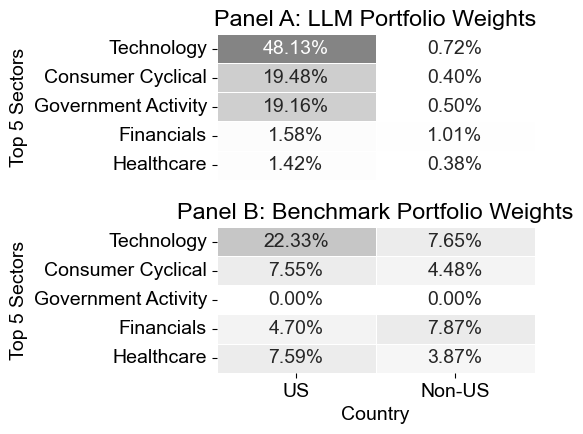

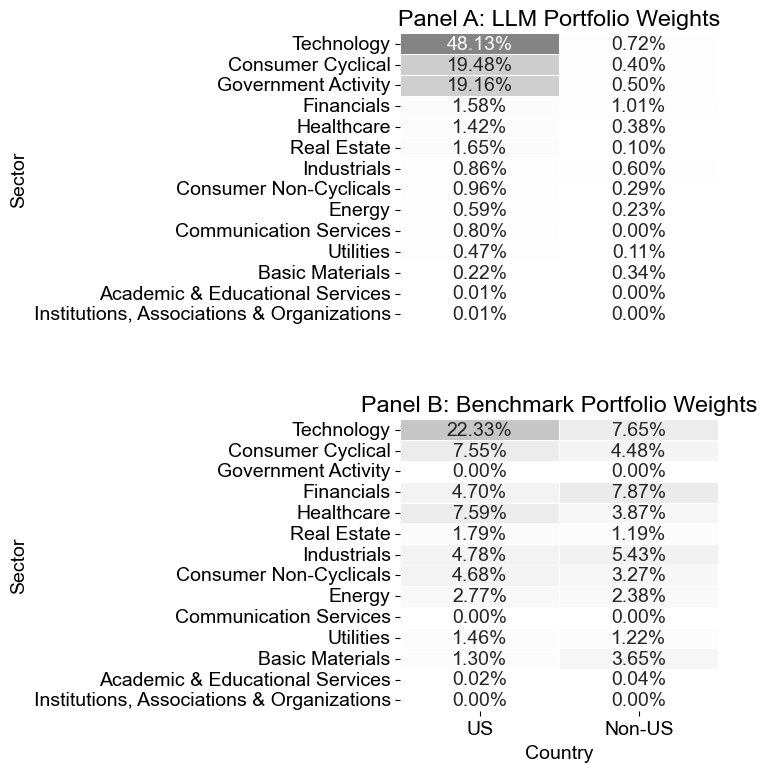

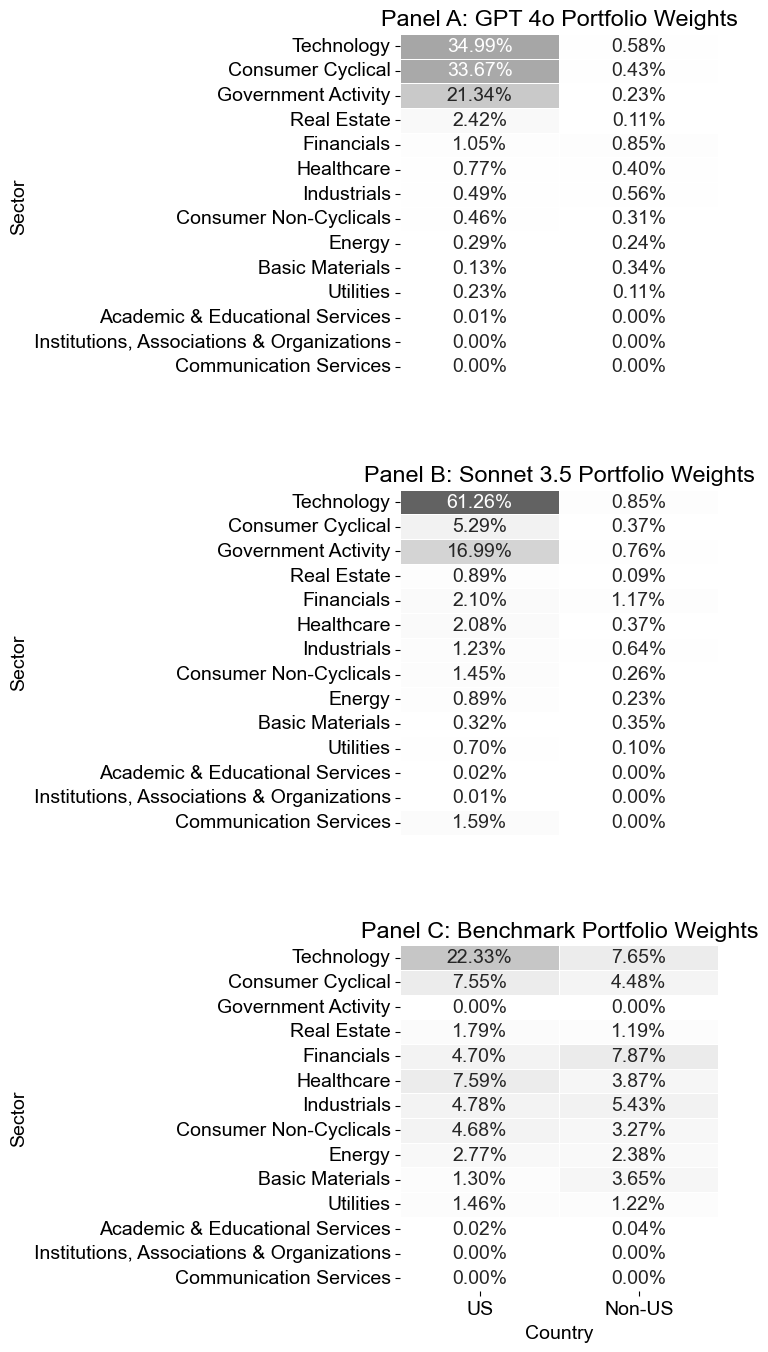

In [31]:
def fill_concentration(filtered_df, res, group_cols):
    sectors = filtered_df['sector'].unique()
    countries = filtered_df['country'].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame(
        [row + [sector, country] for row in group_cols_df.values.tolist() for sector, country in itertools.product(sectors, countries)], 
        columns=group_cols+['sector', 'country'])

    merged_df = pd.merge(all_combinations, res, on=group_cols+['sector', 'country'], how='left')
    merged_df.fillna(0, inplace=True)
    return merged_df

def custom_heatmap(data, color_map="gray_r", annot=True, fmt=".2%", ax=None, max_color=None, **kwargs):
    sns.heatmap(data, cmap=color_map, annot=annot, fmt=fmt, linewidths=.5, cbar=False, ax=ax, vmax=max_color, **kwargs)

import numpy as np

def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).nlargest(5).index
    else:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(index=row_order, fill_value=0)
        facet_pivot = facet_pivot.reindex(columns=facet_pivot.columns[::-1], fill_value=0)  # Reverse column order
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        ax.set_yticks(np.arange(len(facet_pivot.index)) + 0.5)
        ax.set_yticklabels(facet_pivot.index, va='center')  # Set y-tick labels
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    y_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels("Country", y_label)
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'LLM'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['ai'] 

combined = pd.concat([concentration_overview, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined, 'robustness_overview_concentration_map', True, 4, 4)
show_faceted_heatmap(combined, 'robustness_concentration_map', False, 4, 8)

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'robustness_concentration_map_details', False, 4, 14)

## Active investment allocation risk

In [32]:
ter_data_study1 = pd.read_csv('../study1/etf_holdings/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study1 = ter_data_study1.iloc[1:].reset_index()
ter_data_study1.columns = ['fund', 'fund_type', 'ter', 'management_approach']
ter_data_study1 = ter_data_study1[~ter_data_study1['management_approach'].isna()]

ter_data_study2b = pd.read_csv('../study2b/data/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study2b = ter_data_study2b.iloc[1:].reset_index()
ter_data_study2b.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study2a = pd.read_csv('../study2a/data/refinitiv/ter_study2a.csv', index_col=0)
ter_data_study2a = ter_data_study2a.iloc[1:].reset_index()
ter_data_study2a.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study3 = pd.read_csv('../study3/data/refinitiv/ter_study3.csv', index_col=0)
ter_data_study3 = ter_data_study3.iloc[1:].reset_index()
ter_data_study3.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_robustness = pd.read_csv('./data/refinitiv/robustness_ter.csv', index_col=0)
ter_data_robustness = ter_data_robustness.iloc[1:].reset_index()
ter_data_robustness.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data = pd.concat([ter_data_study1, ter_data_study2b, ter_data_study2a, ter_data_study3, ter_data_robustness], ignore_index=True)
ter_data['fund'] = ter_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('Unable to')
ter_data.loc[condition & ~ter_data['ter'].isna(), 'ter'] = np.nan

In [33]:
df_tmp['asset_type'].replace('Saving', 'SAVING', inplace=True)

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/2079764132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_tmp['asset_type'].replace('Saving', 'SAVING', inplace=True)


In [34]:
management_dict = {}

In [35]:
def set_management_approach(row):
    if row['asset_type'] in ['EQUITY', 
                               'CRYPTOCURRENCY', 
                               'BOND', 
                               'MONEYMARKET', 
                               'SEEDINVEST', 
                               'REALESTATE', 
                               'ROBO', 
                               'VENTURECAPITAL',
                               'PRIVATEEQUITY']:
        return 'Active'
    else:
        ticker = row['ticker_symbol']
        if ticker in management_dict:
            return management_dict[ticker]
        else:
            if ticker in ter_data['fund'].unique():
                approach = ter_data[ter_data['fund'] == ticker].iloc[0]['management_approach']
                management_dict[ticker] = approach
                return approach
            else:
                management_dict[ticker] = 'UNKNOWN'
                return 'UNKNOWN'

def calculate_approach_weight(group):
    summed = group.groupby('management_approach')['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['management_weight'] = summed['amount_to_invest'] / total_amount
    return summed

def get_management_data(df, groups):
    df = df[df['management_approach'] != 'UNKNOWN']
    management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
    return management_data      

investment_df = df_tmp[~df_tmp['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_df = investment_df.copy()
investment_df['management_approach'] = investment_df.progress_apply(set_management_approach, axis=1)
management_data = get_management_data(investment_df, group_cols)
management_data = prepare_dataframe(management_data, 'management_weight', 'management_approach', ['Active', 'Passive'])
management_data = management_data[management_data['management_approach'] == 'Active']
management_data['management_weight'] = management_data['management_weight'] *100

100%|██████████████████████████████████████| 470/470 [00:00<00:00, 39173.40it/s]
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/2174045454.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/4235887395.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

TtestResult(statistic=1.8696560116298693, pvalue=0.06485694119728531, df=88.0)
group1: GPT 4o and group2: Sonnet 3.5 got t: 1.87, p_value: 0.0649, df: 88
group: ('GPT 4o',) got t: 8.91 p_value: 0.0 dfs: 44 benchmark: 0 d: 56.22
group: ('Sonnet 3.5',) got t: 8.08 p_value: 0.0 dfs: 44 benchmark: 0 d: 41.07
means:
ai
GPT 4o        56.22
Sonnet 3.5    41.07
Name: management_weight, dtype: float64
stds:
ai
GPT 4o        42.31
Sonnet 3.5    34.12
Name: management_weight, dtype: float64
ai
GPT 4o        45
Sonnet 3.5    45
Name: management_weight, dtype: int64


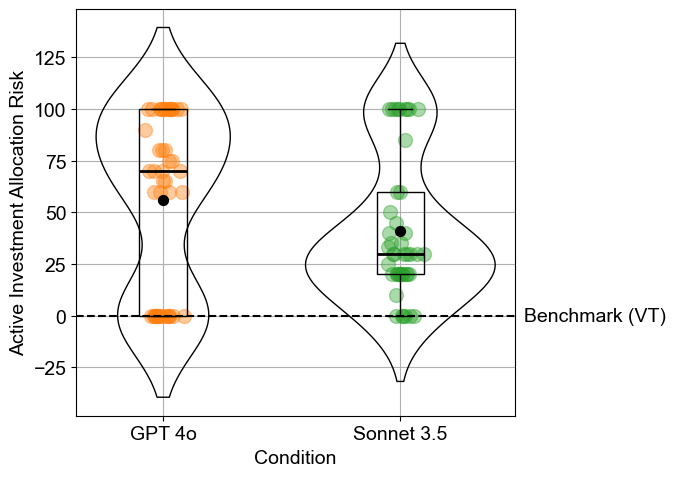

In [36]:
show_benchmark_violinplot(
    management_data, 
    0, 
    'Benchmark (VT)', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'ai',
    'robustness_activeRisk'
)

In [37]:
unused = print_stats(management_data, 'management_weight', 0, 'ai', 'risk_taking')

                 sum_sq    df          F        PR(>F)
label     120949.043210   5.0  143.20296  1.410750e-39
Residual   14189.259259  84.0        NaN           NaN
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
        group1                group2        meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------------
     (GPT 4o, averse)     (GPT 4o, neutral)  69.3333    0.0   55.492  83.1747   True
     (GPT 4o, averse)     (GPT 4o, seeking)  99.3333    0.0   85.492 113.1747   True
     (GPT 4o, averse)  (Sonnet 3.5, averse)     14.0 0.0458   0.1587  27.8413   True
     (GPT 4o, averse) (Sonnet 3.5, neutral)  27.8889    0.0  14.0475  41.7302   True
     (GPT 4o, averse) (Sonnet 3.5, seeking)  81.3333    0.0   67.492  95.1747   True
    (GPT 4o, neutral)     (GPT 4o, seeking)     30.0    0.0  16.1587  43.8413   True
    (GPT 4o, neutral)  (Sonnet 3.5, averse) -55.3333    0.0 -69.1747  

In [38]:
unused = print_stats(management_data, 'management_weight', 0, 'ai', 'age')

                 sum_sq    df         F    PR(>F)
label       7862.376543   5.0  1.037808  0.400945
Residual  127275.925926  84.0       NaN       NaN
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
    (GPT 4o, 15)     (GPT 4o, 30)  -1.3333    1.0 -42.7878 40.1211  False
    (GPT 4o, 15)     (GPT 4o, 50)     -4.0 0.9998 -45.4545 37.4545  False
    (GPT 4o, 15) (Sonnet 3.5, 15) -27.1111 0.4049 -68.5656 14.3434  False
    (GPT 4o, 15) (Sonnet 3.5, 30) -14.6667 0.9059 -56.1211 26.7878  False
    (GPT 4o, 15) (Sonnet 3.5, 50)     -9.0 0.9882 -50.4545 32.4545  False
    (GPT 4o, 30)     (GPT 4o, 50)  -2.6667    1.0 -44.1211 38.7878  False
    (GPT 4o, 30) (Sonnet 3.5, 15) -25.7778 0.4628 -67.2323 15.6767  False
    (GPT 4o, 30) (Sonnet 3.5, 30) -13.3333 0.9354 -54.7878 28.1211  False
    (GPT 4o, 30) (Sonnet 3.5, 50)  -

## Total Expense Risk

In [39]:
fund_identifiers = ter_data['fund'].unique()

# Assigns the TER of an asset depending on the ticker symbol
def assign_ter(row):
    ticker = row['ticker_symbol']
    if ticker in fund_identifiers:
        return ter_data[ter_data['fund'] == ticker].iloc[0]['ter']
    else: 
        return np.nan

# Calculates the weight of an asset within a portfolio
def calculate_fund_weight(group, elem):
    summed = group.groupby(elem)['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['weight'] = summed['amount_to_invest'] / total_amount
    return summed

ter_benchmark = float(ter_data[ter_data['fund'] == 'VT'].iloc[0]['ter'])
ter_benchmark = ter_benchmark

filtered_df = df_tmp[df_tmp['asset_type'].isin(['ETF', 'MUTUALFUND'])]
ter_df = filtered_df.copy()
ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()
ter_df['ter'] = ter_df.apply(assign_ter, axis=1)
ter_df['ter'] = ter_df['ter'].astype(float)
ter_df['ter_weight'] = ter_df['ter'] * ter_df['weight']
grouped_ter = ter_df.groupby(group_cols)['ter_weight'].sum().reset_index()

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/120290630.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()


TtestResult(statistic=0.6349120453402842, pvalue=0.5271331419614114, df=88.0)
group1: GPT 4o and group2: Sonnet 3.5 got t: 0.63, p_value: 0.5271, df: 88
group: ('GPT 4o',) got t: 4.88 p_value: 0.0 dfs: 44 benchmark: 0.07 d: 0.23
group: ('Sonnet 3.5',) got t: 4.25 p_value: 0.0001 dfs: 44 benchmark: 0.07 d: 0.19
means:
ai
GPT 4o        0.30
Sonnet 3.5    0.26
Name: ter_weight, dtype: float64
stds:
ai
GPT 4o        0.32
Sonnet 3.5    0.30
Name: ter_weight, dtype: float64
ai
GPT 4o        45
Sonnet 3.5    45
Name: ter_weight, dtype: int64


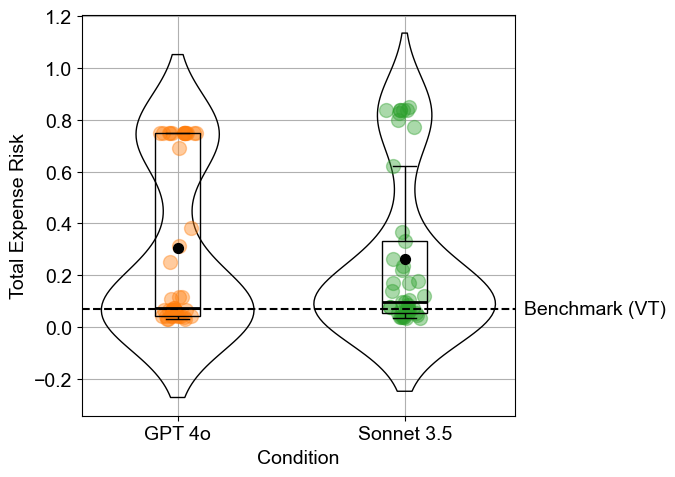

In [40]:
show_benchmark_violinplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark (VT)', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'ai',
    'robustness_terRisk'
)

In [41]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'ai', 'risk_taking')

            sum_sq    df           F        PR(>F)
label     7.514872   5.0  106.928002  6.561028e-35
Residual  1.180700  84.0         NaN           NaN
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
     (GPT 4o, averse)     (GPT 4o, neutral)   0.0592 0.7467 -0.0671  0.1854  False
     (GPT 4o, averse)     (GPT 4o, seeking)   0.6912    0.0  0.5649  0.8174   True
     (GPT 4o, averse)  (Sonnet 3.5, averse)   0.0032    1.0  -0.123  0.1295  False
     (GPT 4o, averse) (Sonnet 3.5, neutral)   0.0443  0.909  -0.082  0.1705  False
     (GPT 4o, averse) (Sonnet 3.5, seeking)   0.5769    0.0  0.4506  0.7031   True
    (GPT 4o, neutral)     (GPT 4o, seeking)    0.632    0.0  0.5057  0.7583   True
    (GPT 4o, neutral)  (Sonnet 3.5, averse)  -0.0559 0.7887 -0.1822  0.0703  False
    (GPT 4o, neut

In [42]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'ai', 'age')

            sum_sq    df        F    PR(>F)
label     0.445070   5.0  0.90627  0.481051
Residual  8.250501  84.0      NaN       NaN
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
    (GPT 4o, 15)     (GPT 4o, 30)   0.0054    1.0 -0.3284 0.3391  False
    (GPT 4o, 15)     (GPT 4o, 50)   0.0647  0.993 -0.2691 0.3984  False
    (GPT 4o, 15) (Sonnet 3.5, 15)  -0.1463 0.7961   -0.48 0.1875  False
    (GPT 4o, 15) (Sonnet 3.5, 30)   0.0485 0.9982 -0.2853 0.3823  False
    (GPT 4o, 15) (Sonnet 3.5, 50)   0.0418 0.9991 -0.2919 0.3756  False
    (GPT 4o, 30)     (GPT 4o, 50)   0.0593 0.9953 -0.2745 0.3931  False
    (GPT 4o, 30) (Sonnet 3.5, 15)  -0.1516 0.7704 -0.4854 0.1821  False
    (GPT 4o, 30) (Sonnet 3.5, 30)   0.0431  0.999 -0.2906 0.3769  False
    (GPT 4o, 30) (Sonnet 3.5, 50)   0.0365 0.9995 -0.2973 0.3702  False
    

## Trend Chasing Risk

Here we are more interested in macro-level trends (trends that persist over a longer period of time). Therefore, we test this against the
trends when the original dataset was sourced (additionally we do not have data over the period of 3 months following the new data collection).

In [43]:
vt_prepared = benchmark_vt
vt_prepared['symbol'] = vt_prepared['symbol'].str.split('.').str[0]
vt_equities = vt_prepared['symbol'].unique()

volume_dict = {}
start_date = "2023-04-01"
end_date = "2023-06-30"

In [44]:
json_file_path = '../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json'
with open(json_file_path, 'r') as json_file:
    volume_dict = json.load(json_file)
    
most_active_stocks = sorted(volume_dict.items(), key=lambda x: x[1], reverse=True)

# Most traded in the last 3 months by volume
for i, (symbol, volume) in enumerate(most_active_stocks[:20], 1):
    print(f"{i}. Symbol: {symbol}, Total Volume: {volume}")

1. Symbol: TSLA, Total Volume: 8627649000
2. Symbol: PLTR, Total Volume: 4490639300
3. Symbol: AMD, Total Volume: 4201460900
4. Symbol: AMZN, Total Volume: 3899624000
5. Symbol: F, Total Volume: 3708650700
6. Symbol: AAPL, Total Volume: 3541966300
7. Symbol: NIO, Total Volume: 3235177200
8. Symbol: SOFI, Total Volume: 3204363300
9. Symbol: BAC, Total Volume: 3044131000
10. Symbol: NKLA, Total Volume: 3010655200
11. Symbol: NVDA, Total Volume: 2965437300
12. Symbol: INTC, Total Volume: 2762170900
13. Symbol: CCL, Total Volume: 2498772900
14. Symbol: T, Total Volume: 2442695800
15. Symbol: GOOGL, Total Volume: 2081408400
16. Symbol: LCID, Total Volume: 1905241200
17. Symbol: AI, Total Volume: 1890107300
18. Symbol: NU, Total Volume: 1711794600
19. Symbol: MSFT, Total Volume: 1699893000
20. Symbol: PACW, Total Volume: 1662858500


In [45]:
# Determines the assets with the highest money allocation in GenAI advice
def getTop(conds, cond, equities_cond, equities_grouped):
    top_data = {}
    
    for co in conds:
        top_equities_total = equities_cond[equities_cond['ai'] == co]['amount_to_invest']
        top_total = cond[cond['ai'] == co]['amount_to_invest']
        top_cond = equities_grouped[equities_grouped['ai'] == co]
        top_cond = top_cond.copy()
        top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
        top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
        top_cond = top_cond.sort_values(by='amount_to_invest', ascending=False)
        top_data[co] = top_cond
        
    return top_data

# Prints the top asset data
def showTop(conds, top_data):
    top_dict = {}
    for co in conds:
        top = top_data[co]
        top_equities_sum = top['pct_of_equities'].sum()
        top_total_sum = top['pct_of_total'].sum()
        print(f'{co} top: % of equities: {top_equities_sum} and % of total {top_total_sum}')

        top3 = top.head(3)
        top3_equities_sum = top3['pct_of_equities'].sum()
        top3_total_sum = top3['pct_of_total'].sum()
        print(f'{co} top 3: % of equities: {top3_equities_sum} and % of total {top3_total_sum}')
        print(f'{top3}\n')
        top_dict[co] = top3['ticker_symbol'].tolist()
    return top_dict
    

ais = df_tmp['ai'].unique()
ageRisk_cond = df_tmp.groupby(['ai'])['amount_to_invest'].sum().reset_index()
ageRisk_equities = df_tmp[df_tmp['asset_type'] == 'EQUITY']
ageRisk_equities_cond = ageRisk_equities.groupby(['ai'])['amount_to_invest'].sum().reset_index()
ageRisk_equities_grouped = ageRisk_equities.groupby(['ai','ticker_symbol'])['amount_to_invest'].sum().reset_index()

top_data = getTop(ais, ageRisk_cond, ageRisk_equities_cond, ageRisk_equities_grouped)
top_dict = showTop(ais, top_data)

GPT 4o top: % of equities: 1.0 and % of total 0.38222222222222224
GPT 4o top 3: % of equities: 0.7005813953488372 and % of total 0.2677777777777778
       ai ticker_symbol  amount_to_invest  pct_of_equities  pct_of_total
7  GPT 4o          TSLA             70500         0.409884      0.156667
0  GPT 4o          AAPL             30000         0.174419      0.066667
5  GPT 4o          PLTR             20000         0.116279      0.044444

Sonnet 3.5 top: % of equities: 1.0 and % of total 0.24
Sonnet 3.5 top 3: % of equities: 0.6898148148148149 and % of total 0.16555555555555557
            ai ticker_symbol  amount_to_invest  pct_of_equities  pct_of_total
15  Sonnet 3.5          NVDA             30500         0.282407      0.067778
13  Sonnet 3.5          MSFT             29500         0.273148      0.065556
9   Sonnet 3.5          AAPL             14500         0.134259      0.032222



In [46]:
top3_benchmark = vt_dummy.sort_values(by='weight', ascending=False).head(3) 
top3_benchmark #all included in top 20 most traded

,fund,code,equity,symbol,#shares,weight,country,type,sector,amount,cond,ai,age,risk_taking,iteration
93854,VT,LP40120747,APPLE INC ORD,AAPL,8132495.0,0.038911,UNITED STATES,Ordinary Shares,Technology,389.11,VT,VT,1,low,0
93855,VT,NaN,MICROSOFT CORP ORD,MSFT,4055679.0,0.033854,UNITED STATES,Ordinary Shares,Technology,338.54,VT,VT,1,low,0
93856,VT,NaN,AMAZON.COM INC ORD,AMZN,4909845.0,0.017257,UNITED STATES,Ordinary Shares,Consumer Cyclical,172.57,VT,VT,1,low,0


In [47]:
# Calculates the share of the top 3 assets by volume in GenAI advice
def calcTopMeans(df, top_dict):
    top_df = None

    for ai, top_assets in top_dict.items():
        filtered_df = df[(df['ai'] == ai) & (df['ticker_symbol'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])
    
    top_df = prepare_dataframe(top_df, 'weight')    
    result = top_df.groupby(['ai', 'age', 'risk_taking', 'iteration'])['weight'].sum().reset_index()
    return result
 
benchmark_trends = top3_benchmark.groupby('ai')['weight'].sum().reset_index().iloc[0]['weight']
trends_data = calcTopMeans(df_resolved, top_dict)

trends_data['weight'] = trends_data['weight'] *100
benchmark_trends = benchmark_trends * 100

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_6864/4235887395.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result_df[col_name].fillna(0, inplace=True)


TtestResult(statistic=2.737991616442719, pvalue=0.007480309024750888, df=88.0)
group1: GPT 4o and group2: Sonnet 3.5 got t: 2.74, p_value: 0.0075, df: 88
group: ('GPT 4o',) got t: 5.74 p_value: 0.0 dfs: 44 benchmark: 9.0 d: 17.78
group: ('Sonnet 3.5',) got t: 3.62 p_value: 0.0008 dfs: 44 benchmark: 9.0 d: 7.55
means:
ai
GPT 4o        26.78
Sonnet 3.5    16.56
Name: weight, dtype: float64
stds:
ai
GPT 4o        20.76
Sonnet 3.5    14.01
Name: weight, dtype: float64
ai
GPT 4o        45
Sonnet 3.5    45
Name: weight, dtype: int64


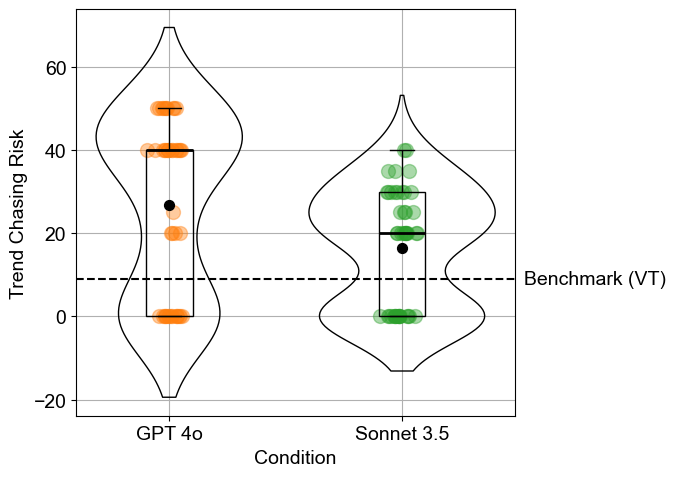

In [48]:
show_benchmark_violinplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark (VT)', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'ai',
    'robustness_trendRisk'
)

In [49]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'ai', 'risk_taking')

           sum_sq    df          F        PR(>F)
label     24720.0   5.0  79.406501  2.381813e-30
Residual   5230.0  84.0        NaN           NaN
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
        group1                group2        meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------------
     (GPT 4o, averse)     (GPT 4o, neutral)     40.0    0.0  31.5967  48.4033   True
     (GPT 4o, averse)     (GPT 4o, seeking)  40.3333    0.0    31.93  48.7366   True
     (GPT 4o, averse)  (Sonnet 3.5, averse)      0.0    1.0  -8.4033   8.4033  False
     (GPT 4o, averse) (Sonnet 3.5, neutral)  26.3333    0.0    17.93  34.7366   True
     (GPT 4o, averse) (Sonnet 3.5, seeking)  23.3333    0.0    14.93  31.7366   True
    (GPT 4o, neutral)     (GPT 4o, seeking)   0.3333    1.0    -8.07   8.7366  False
    (GPT 4o, neutral)  (Sonnet 3.5, averse)    -40.0    0.0 -48.4033 -31.5967   True
   

/opt/homebrew/Caskroom/miniforge/base/envs/llm/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [50]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'ai', 'age')

                sum_sq    df         F    PR(>F)
label      3016.666667   5.0  1.881683  0.106126
Residual  26933.333333  84.0       NaN       NaN
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
    (GPT 4o, 15)     (GPT 4o, 30)   7.6667 0.8486  -11.403 26.7363  False
    (GPT 4o, 15)     (GPT 4o, 50)   5.6667 0.9534  -13.403 24.7363  False
    (GPT 4o, 15) (Sonnet 3.5, 15)     -4.0 0.9899 -23.0697 15.0697  False
    (GPT 4o, 15) (Sonnet 3.5, 30)  -4.6667 0.9798 -23.7363  14.403  False
    (GPT 4o, 15) (Sonnet 3.5, 50)  -8.6667 0.7701 -27.7363  10.403  False
    (GPT 4o, 30)     (GPT 4o, 50)     -2.0 0.9996 -21.0697 17.0697  False
    (GPT 4o, 30) (Sonnet 3.5, 15) -11.6667 0.4813 -30.7363   7.403  False
    (GPT 4o, 30) (Sonnet 3.5, 30) -12.3333 0.4177  -31.403  6.7363  False
    (GPT 4o, 30) (Sonnet 3.5, 50) -16.3

## MANOVA

In [ ]:
geo_us.rename(columns={'weight': 'us_weight'}, inplace=True)
trends_data.rename(columns={'weight': 'trends_weight'}, inplace=True)
print(geo_us.shape)
print(sec.shape)
print(management_data.shape)
print(grouped_ter.shape)
print(trends_data.shape)

In [ ]:
df_metrics = geo_us.merge(
    sec[['ai', 'age', 'risk_taking', 'iteration', 'concentration']], 
    on=['ai', 'age', 'risk_taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    management_data[['ai', 'age', 'risk_taking', 'iteration', 'management_weight']], 
    on=['ai', 'age', 'risk_taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    grouped_ter[['ai', 'age', 'risk_taking', 'iteration', 'ter_weight']], 
    on=['ai', 'age', 'risk_taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    trends_data[['ai', 'age', 'risk_taking', 'iteration', 'trends_weight']], 
    on=['ai', 'age', 'risk_taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.dropna()

In [ ]:
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ ai', data = df_metrics)
print(manova.mv_test())

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ ai + risk_taking + age', data = df_metrics)
print(manova.mv_test())

In [ ]:
group_levels = df_metrics['ai'].unique()

# Run MANOVA separately for each level of 'llm'
for level in group_levels:
    subset = df_metrics[df_metrics['ai'] == level]  # Subset data for a specific group level
    
    print(f'\nMANOVA for llm: {level}')
    manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ risk_taking + age', data=subset)
    print(manova.mv_test())